# Quickstart: GFS vs ECMWF AIFS heating degree days at BNA - dynamical.org Icechunk Zarr

Say you have an model or analysis that uses a weather forecast as input. 

You're probably pretty excited to try out the rapidly proliferating AI weather forecasts, right? But building a new pipeline, understanding the init time nuances, issuance lacency, file structure, and on and on - it can be a lot of work. But it should be boring!

This notebook: 
1. Computes Heating Degree Days (HDD) at Nashville International Airport (BNA) from NOAA GFS. 
2. Demonstrates a few-character change to swap in ECMWF AIFS forecasts.
3. Compares GFS and AIFS against hourly airport weather station observations from ASOS. 

HDD is just a deterministic transform of temperature, so this is a clean little test: swap the forecast model, keep everything downstream the same, and see what happens.

That is the point of the dynamical.org catalog. No format spelunking, no variable-name bingo, no special-case pipeline because one model came from a different institution with different ideas about coordinates. Open the store, run the analysis.

Datasets used:
- [NOAA GFS forecast](https://dynamical.org/catalog/noaa-gfs-forecast/)
- [ECMWF AIFS Single forecast](https://dynamical.org/catalog/ecmwf-aifs-single-forecast/)
- [ASOS Parquet](https://dynamical.org/catalog/asos-parquet/) - hourly global airport observations

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog duckdb

In [2]:
import duckdb
import dynamical_catalog
import matplotlib.pyplot as plt
import pandas as pd

## 1. Load GFS and plot a forecast at BNA

We will start with NOAA GFS, the U.S. flagship deterministic global model. We'll use `x="valid_time"` to label the x-axis using the dataset's built in coordinate labels.

In [3]:
gfs_ds = dynamical_catalog.open("noaa-gfs-forecast", chunks=None)
gfs_ds

<xarray.Dataset> Size: 133TB
Dimensions:                                     (init_time: 7275,
                                                 lead_time: 209, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 58kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 58kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 58kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 2kB ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 12MB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/21)
    categorical_freezing_rain_surface           (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_ice_pellets_surface             (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_rain_surface                    (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_snow_surface                    (init_time, lead_time, latitude, longitude) float32 6TB ...
    geopotential_height_cloud_ceiling           (init_time, lead_time, latitude, longitude) float32 6TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 6TB ...
    ...                                          ...
    relative_humidity_2m                        (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 6TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 6TB ...
Attributes:
    dataset_id:           noaa-gfs-forecast
    dataset_version:      0.2.7
    name:                 NOAA GFS forecast
    description:          Weather forecasts from the Global Forecast System (...
    attribution:          NOAA NWS NCEP GFS data processed by dynamical.org f...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2021-05-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-384 hours (0-16 days) ahead
    forecast_resolution:  Forecast step 0-120 hours: hourly, 123-384 hours: 3...

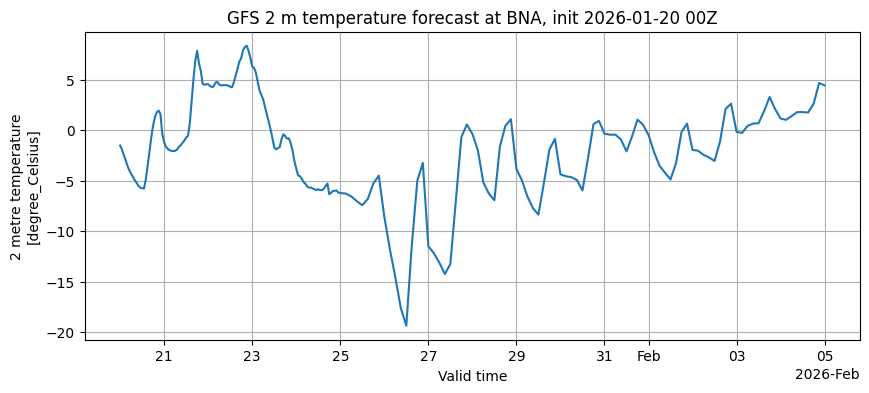

In [4]:
BNA_LAT = 36.119
BNA_LON = -86.689

fig, ax = plt.subplots(figsize=(10, 4))
gfs_ds["temperature_2m"].sel(
    init_time="2026-01-20T00", latitude=BNA_LAT, longitude=BNA_LON, method="nearest"
).plot(x="valid_time", ax=ax)
ax.set_title("GFS 2 m temperature forecast at BNA, init 2026-01-20 00Z")
ax.grid()

## 2. Load AIFS and plot the same forecast at BNA

Now do the same thing with ECMWF's Artificial Intelligence Forecasting System (AIFS Single). Very different model under the hood. We've set it up to have the same dimension names, the same variable names, and the same basic access pattern as GFS, so the selection code below is basically a find-and-replace on the dataset name. Physics-based forecast, AI-based forecast, same downstream code.

In [5]:
aifs_ds = dynamical_catalog.open("ecmwf-aifs-single-forecast", chunks=None)
aifs_ds

<xarray.Dataset> Size: 13TB
Dimensions:                                     (init_time: 3011,
                                                 lead_time: 61, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 24kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 24kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 24kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 1MB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/17)
    dew_point_temperature_2m                    (init_time, lead_time, latitude, longitude) float32 763GB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 763GB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 763GB ...
    geopotential_height_925hpa                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    geopotential_height_850hpa                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    geopotential_height_500hpa                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    ...                                          ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    temperature_925hpa                          (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 763GB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 763GB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 763GB ...
Attributes:
    dataset_id:           ecmwf-aifs-single-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS Single forecast
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS Single forecast data processed by dynami...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

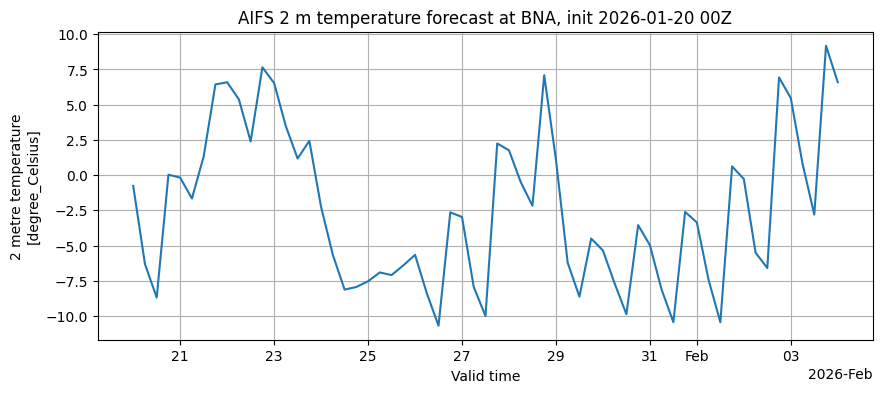

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
aifs_ds["temperature_2m"].sel(
    init_time="2026-01-20T00", latitude=BNA_LAT, longitude=BNA_LON, method="nearest"
).plot(x="valid_time", ax=ax)
ax.set_title("AIFS 2 m temperature forecast at BNA, init 2026-01-20 00Z")
ax.grid()

## 3. HDD analysis function

**Heating Degree Days (HDD)** measure how cold a day is relative to a 65 deg F (18.333 deg C) base, roughly the point below which buildings start needing heat. The canonical definition is

$$\mathrm{HDD} = \max(0,\; T_{\text{base}} - T_{\text{avg}}) \quad\text{where}\quad T_{\text{avg}} = (T_{\max} + T_{\min}) / 2$$

Temperature goes in, HDD comes out. If one forecast model produces better temperatures, that improvement passes straight through.

Below we:
1. Pull hourly ASOS observations (basically a data product collecting airport weather stations) for BNA and compute observed HDD as ground truth.
2. Define a single `hdd_analysis` function that works on any dataset exposing `temperature_2m(init_time, lead_time, latitude, longitude)`.
3. Compute forecast HDD at 1-day, 3-day, and 5-day lead.

In [7]:
STATION = "BNA"
START = "2025-12-01"
END = "2026-03-01"
HDD_BASE_C = (65 - 32) * 5 / 9  # 18.333 °C
LEADS_DAYS = [1, 3, 5]


def load_station_obs(station, start, end):
    base = "https://data.source.coop/dynamical/asos-parquet"
    urls = [f"{base}/year={y}/data.parquet" for y in range(int(start[:4]), int(end[:4]) + 1)]
    df = duckdb.execute(
        """
        SELECT valid, tmpc, latitude, longitude
        FROM read_parquet(?, hive_partitioning=true)
        WHERE station = ? AND valid BETWEEN ? AND ? AND tmpc IS NOT NULL
        ORDER BY valid
        """,
        [urls, station, start, end],
    ).fetchdf()
    obs = df.set_index("valid")["tmpc"]
    obs.index = obs.index.tz_localize(None)
    return float(df["latitude"].iloc[0]), float(df["longitude"].iloc[0]), obs


station_lat, station_lon, obs = load_station_obs(STATION, START, END)
print(f"{STATION}: ({station_lat:.3f}, {station_lon:.3f}), {len(obs)} hourly obs")

BNA: (36.119, -86.689), 2368 hourly obs


In [8]:
t_daily = obs.resample("1D").agg(["max", "min"]).dropna()
obs_hdd = (HDD_BASE_C - t_daily.mean(axis=1)).clip(lower=0)
target_days = obs_hdd.index
print(f"Observed HDD: {len(obs_hdd)} days, sum={obs_hdd.sum():.0f}, max={obs_hdd.max():.1f}")
obs_hdd.head()

Observed HDD: 90 days, sum=1133, max=28.1


valid
2025-12-01    16.943333
2025-12-02    17.778333
2025-12-03    17.778333
2025-12-04    16.668333
2025-12-05    16.668333
Freq: D, dtype: float64

In [9]:
def hdd_analysis(ds, station_lat, station_lon, target_days):
    max_lead = max(LEADS_DAYS)
    t2m_point = (
        ds["temperature_2m"]
        .sel(init_time=slice(target_days[0] - pd.Timedelta(days=max_lead), target_days[-1]))
        .sel(latitude=station_lat, longitude=station_lon, method="nearest")
        .load()
    )

    columns = {}
    for lead_days in LEADS_DAYS:
        lead_str = f"{lead_days}d"
        sub = t2m_point.sel(lead_time=slice(lead_str, lead_str)).reindex(
            init_time=target_days - pd.Timedelta(days=lead_days)
        )
        t_avg = (sub.max("lead_time") + sub.min("lead_time")) / 2
        columns[lead_str] = (HDD_BASE_C - t_avg).clip(min=0).values
    return pd.DataFrame(columns, index=target_days)

## 4. Run the analysis on GFS

In [10]:
gfs_hdd = hdd_analysis(gfs_ds, station_lat, station_lon, target_days)
gfs_hdd.head()

,1d,3d,5d
valid,,,
2025-12-01,16.302084,15.708334,16.792318
2025-12-02,16.574057,14.036459,14.704428
2025-12-03,15.669271,15.098959,15.177084
2025-12-04,14.317709,13.966146,10.223959
2025-12-05,14.559896,14.778646,14.020834


## 5. Run the analysis on AIFS

Same function, different forecast source. `hdd_analysis` does not care whether the temperature field came from a traditional numerical weather model or a neural network trained on decades of reanalysis. It just expects a dataset with the agreed-upon schema and gets on with it.

In [11]:
aifs_hdd = hdd_analysis(aifs_ds, station_lat, station_lon, target_days)
aifs_hdd.head()

,1d,3d,5d
valid,,,
2025-12-01,18.075521,19.009115,19.667318
2025-12-02,16.087240,16.360678,15.763021
2025-12-03,18.360678,17.649740,16.473959
2025-12-04,16.739584,15.462240,15.871420
2025-12-05,16.501303,16.835287,13.716146


## 6. Compare performance

Compute RMSE, MAE, and bias of each model's HDD forecast against observed HDD at each lead time, then plot them side by side to answer the practical question: if you swap the weather model and touch nothing else, do you get a better result?

In [12]:
def metrics(forecast_hdd, obs_hdd):
    err = forecast_hdd.sub(obs_hdd, axis=0)
    return pd.DataFrame({
        "count": err.count(),
        "RMSE": (err ** 2).mean() ** 0.5,
        "MAE": err.abs().mean(),
        "bias": err.mean(),
    })


gfs_metrics = metrics(gfs_hdd, obs_hdd)
aifs_metrics = metrics(aifs_hdd, obs_hdd)
comparison = pd.concat({"GFS": gfs_metrics, "AIFS": aifs_metrics}, axis=1)
comparison.round(2)

GFS                    AIFS                  
   count  RMSE   MAE  bias count  RMSE   MAE  bias
1d    90  1.91  1.41  0.04    90  2.15  1.60 -0.17
3d    90  2.27  1.74  0.07    90  2.40  1.87  0.05
5d    90  3.50  2.77  0.47    90  3.01  2.31  0.03

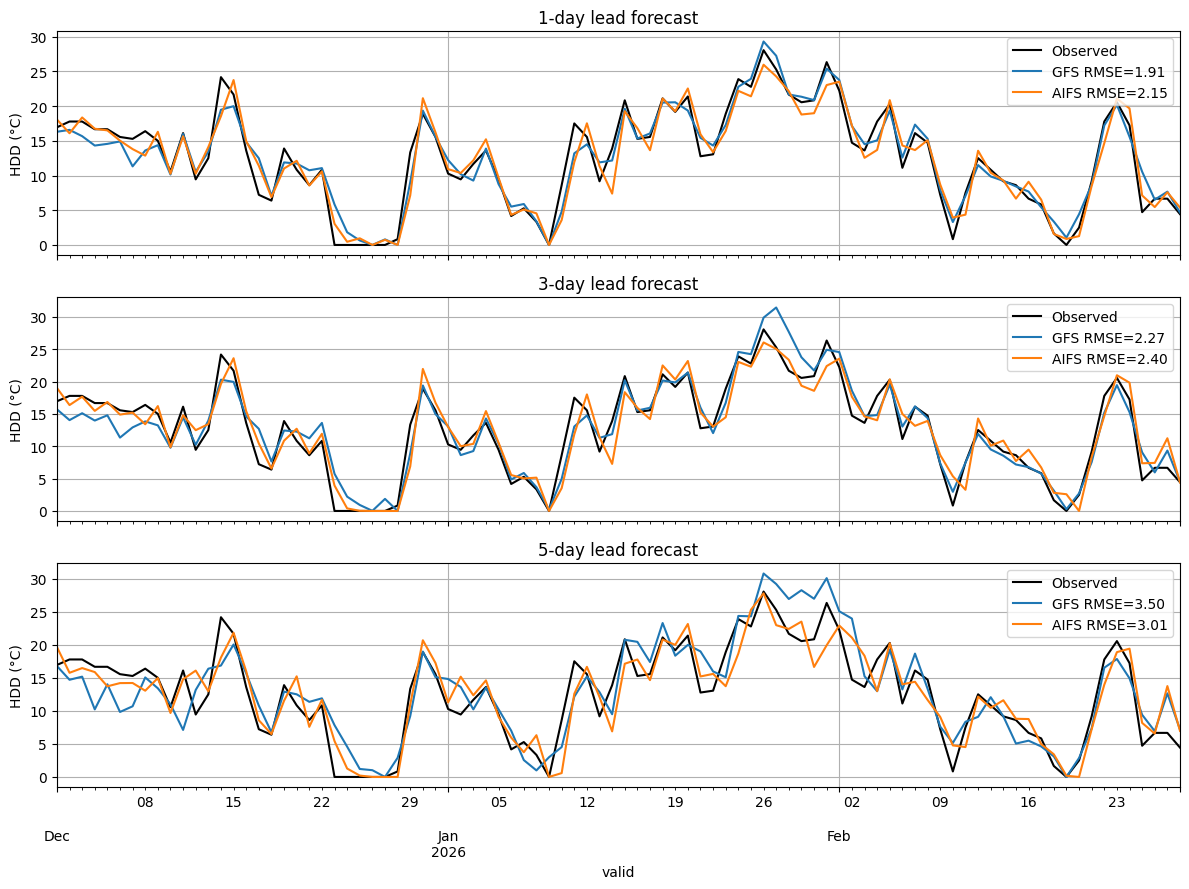

In [13]:
fig, axes = plt.subplots(len(LEADS_DAYS), 1, figsize=(12, 9), sharex=True)
for ax, lead_days in zip(axes, LEADS_DAYS):
    col = f"{lead_days}d"
    obs_hdd.plot(ax=ax, color="black", label="Observed")
    gfs_hdd[col].plot(ax=ax, label=f"GFS RMSE={gfs_metrics.loc[col, 'RMSE']:.2f}")
    aifs_hdd[col].plot(ax=ax, label=f"AIFS RMSE={aifs_metrics.loc[col, 'RMSE']:.2f}")
    ax.set_ylabel("HDD (°C)")
    ax.set_title(f"{lead_days}-day lead forecast")
    ax.legend(loc="upper right")
    ax.grid()
fig.tight_layout()

### What to read from the numbers

- **Performance is roughly equal at 1-day lead.** The models are neck-and-neck on day-ahead HDD for this station and window.
- **AIFS pulls ahead as lead time grows.** That is where the newer AI models start to get especially interesting: the advantage is not just that they can be good, it is that they can stay good farther out.
- **AIFS at 5-day lead is roughly comparable to GFS at 3-day lead** in this example, which is a useful way to think about the magnitude of the difference.
- **Same function, two datasets.** The analysis code was never rewritten for AIFS. That is the real product point. Once the data interface is normalized, trying a new weather model stops being a months-long ingestion project and becomes a one-line swap.